In [1]:
import glob
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from matplotlib.animation import FuncAnimation

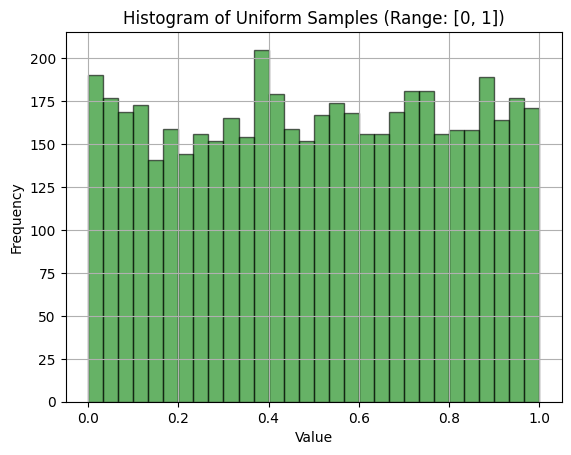

In [2]:
batch_size = 5000
# Generate sample points from a Uniform distribution (range: [low, high])
uniform_samples = np.random.uniform(low=0, high=1, size=batch_size).astype(np.float32)
uniform_samples = torch.tensor(uniform_samples).numpy()

# Plot Histogram
plt.hist(uniform_samples, bins=30, alpha=0.6, color='green', edgecolor='black')
plt.title('Histogram of Uniform Samples (Range: [0, 1])')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

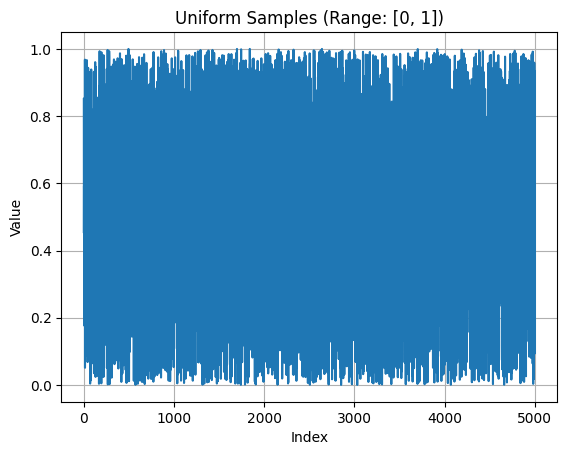

In [3]:
plt.plot(uniform_samples)
plt.title('Uniform Samples (Range: [0, 1])')
plt.xlabel('Index')
plt.ylabel('Value')
plt.grid(True)
plt.show()

Text(0.5, 0, 'Value')

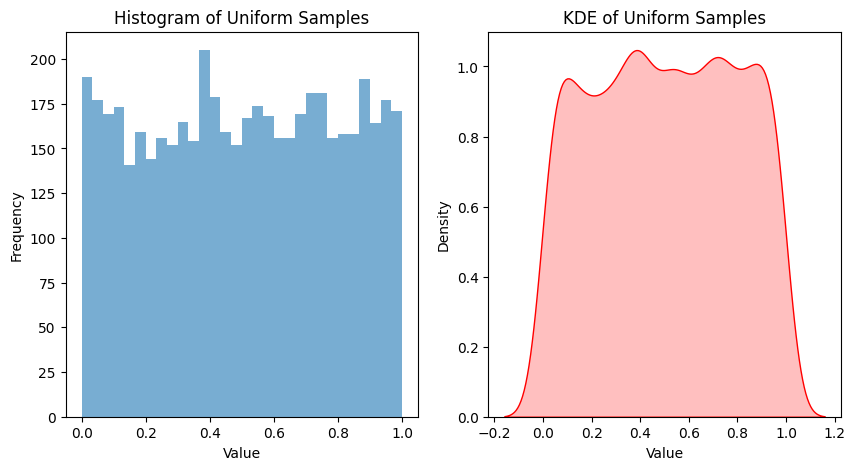

In [4]:
# Plot Histogram
plt.figure(figsize=(10, 5))

# Subplot 1: Histogram
plt.subplot(1, 2, 1)
plt.hist(uniform_samples, bins=30, alpha=0.6)
plt.title('Histogram of Uniform Samples')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Subplot 2: Kernel Density Estimate (KDE)
plt.subplot(1, 2, 2)
sns.kdeplot(uniform_samples, color='red', fill=True)
plt.title('KDE of Uniform Samples')
plt.xlabel('Value')

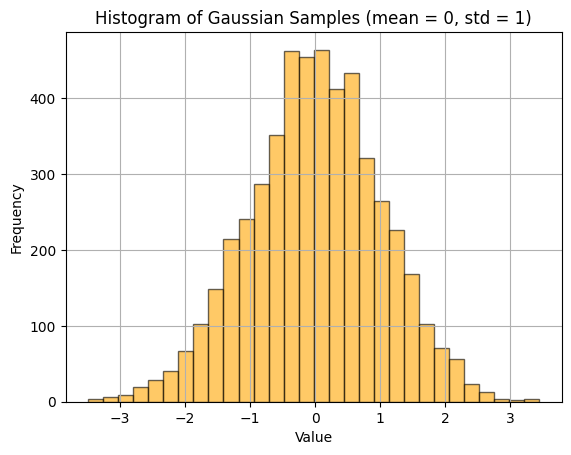

In [5]:
# Step 2: Generate 400 sample points from a Gaussian distribution (mean=0, std=1)
# gaussian_samples = np.random.normal(loc=0, scale=1, size=400).astype(np.float32)
gaussian_samples = norm.ppf(uniform_samples)
gaussian_samples = torch.tensor(gaussian_samples).numpy()

# Plot Histogram
plt.hist(gaussian_samples, bins=30, alpha=0.6, color='orange', edgecolor='black')
plt.title('Histogram of Gaussian Samples (mean = 0, std = 1)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

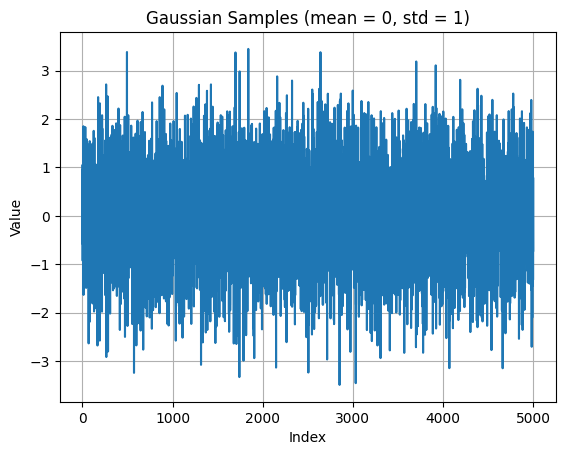

In [6]:
plt.plot(gaussian_samples)
plt.title('Gaussian Samples (mean = 0, std = 1)')
plt.xlabel('Index')
plt.ylabel('Value')
plt.grid(True)
plt.show()

Text(0.5, 0, 'Value')

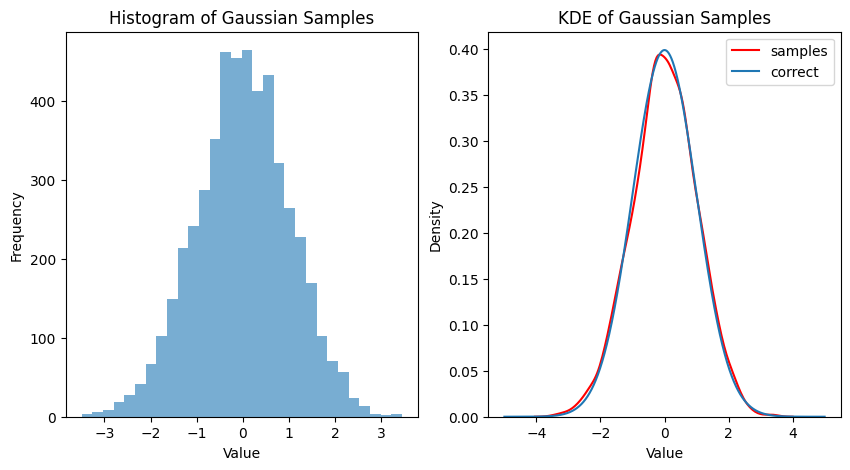

In [7]:
# Plot Histogram
plt.figure(figsize=(10, 5))

# Subplot 1: Histogram
plt.subplot(1, 2, 1)
plt.hist(gaussian_samples, bins=30, alpha=0.6)
plt.title('Histogram of Gaussian Samples')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Subplot 2: Kernel Density Estimate (KDE)
plt.subplot(1, 2, 2)
sns.kdeplot(gaussian_samples, color='red',label='samples')
# Mean = 0, SD = 1.
x_axis = np.arange(-5, 5, 0.0005)
plt.plot(x_axis, norm.pdf(x_axis,0,1), label = 'correct')
plt.legend()
plt.title('KDE of Gaussian Samples')
plt.xlabel('Value')

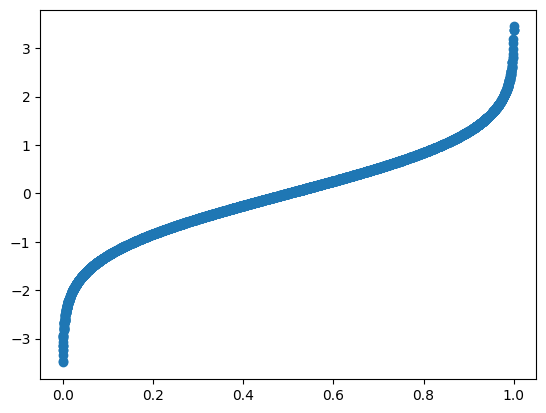

In [8]:
plt.scatter(uniform_samples, gaussian_samples)

In [9]:
uniform_samples = torch.tensor(uniform_samples).unsqueeze(1)
gaussian_samples = torch.tensor(gaussian_samples).unsqueeze(1)

In [10]:
class FNN(nn.Module):
    def __init__(self):
        super(FNN, self).__init__()
        self.fc1 = nn.Linear(1, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, 256)
        self.fc4 = nn.Linear(256, 256)
        self.fc5 = nn.Linear(256, 256)
        self.fc6 = nn.Linear(256, 1)
        self.tanh = nn.Tanh()

    def forward(self, x):
        x = self.tanh(self.fc1(x))
        x = self.tanh(self.fc2(x))
        x = self.tanh(self.fc3(x))
        x = self.tanh(self.fc4(x))
        x = self.tanh(self.fc5(x))
        return self.fc6(x)

In [11]:
# Function to compute moments (mean, variance, skewness, kurtosis, and 5th moment)
def compute_moments(samples):
    mean = torch.mean(samples)
    variance = torch.var(samples, unbiased=False)  # Population variance
    skewness = torch.mean(((samples - mean) ** 3)) / (variance ** 1.5)
    kurtosis = torch.mean(((samples - mean) ** 4)) / (variance ** 2) - 3
    fifth_moment = torch.mean((samples - mean) ** 5)
    return mean, variance, skewness, kurtosis, fifth_moment

In [12]:
def compute_mean(samples):
    mean = torch.mean(samples)
    return mean

In [13]:
def compute_variance(samples):
    variance = torch.var(samples, unbiased=False)
    return variance

In [14]:
def compute_skewness(samples):
    mean = compute_mean(samples)
    variance = compute_variance(samples)
    skewness = torch.mean(((samples - mean) ** 3)) / (variance ** 1.5)
    return skewness

In [15]:
def compute_kurtosis(samples):
    mean = compute_mean(samples)
    variance = compute_variance(samples)
    kurtosis = torch.mean(((samples - mean) ** 4)) / (variance ** 2) - 3
    return kurtosis

In [16]:
def compute_fifth_moment(samples):
    mean = compute_mean(samples)
    fifth_moment = torch.mean((samples - mean) ** 5)
    return fifth_moment

In [17]:
def compute_sixth_moment(samples):
    mean = compute_mean(samples)
    return torch.mean((samples - mean) ** 6)

In [18]:
# Initialize the neural network
model = FNN()

In [19]:
# Define optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Initialize lists to store each moment loss over epochs
mean_loss_list = []
variance_loss_list = []
skewness_loss_list = []
kurtosis_loss_list = []
fifth_moment_loss_list = []
sixth_moment_loss_list = []
total_loss_list = []
epoch_list = []

# Training loop
num_epochs = 10000
save_interval = 50  # Save model every 50 iterations

for epoch in range(num_epochs):
    # Forward pass
    outputs = model(uniform_samples)
    
    # Compute individual moment losses
    mean_loss = (compute_mean(outputs) - compute_mean(gaussian_samples)) ** 2
    variance_loss = (compute_variance(outputs) - compute_variance(gaussian_samples)) ** 2
    skewness_loss = (compute_skewness(outputs) - compute_skewness(gaussian_samples)) ** 2
    kurtosis_loss = (compute_kurtosis(outputs) - compute_kurtosis(gaussian_samples)) ** 2
    fifth_moment_loss = (compute_fifth_moment(outputs) - compute_fifth_moment(gaussian_samples)) ** 2
    sixth_moment_loss = (compute_sixth_moment(outputs) - compute_sixth_moment(gaussian_samples)) ** 2

    # Total loss with weighted moments
    total_loss = (50 * mean_loss + 50 * variance_loss + 10 * skewness_loss + 
                  10 * kurtosis_loss + 0.1 * fifth_moment_loss + 0.1 * sixth_moment_loss)

    # Backward pass and optimization
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()
    
    # Store each moment loss and epoch number
    mean_loss_list.append(mean_loss.item())
    variance_loss_list.append(variance_loss.item())
    skewness_loss_list.append(skewness_loss.item())
    kurtosis_loss_list.append(kurtosis_loss.item())
    fifth_moment_loss_list.append(fifth_moment_loss.item())
    sixth_moment_loss_list.append(sixth_moment_loss.item())
    total_loss_list.append(total_loss.item())
    epoch_list.append(epoch + 1)
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Mean Loss: {mean_loss.item():.5f}, '
          f'Variance Loss: {variance_loss.item():.5f}, Skewness Loss: {skewness_loss.item():.6f}, '
          f'Kurtosis Loss: {kurtosis_loss.item():.6f}, Fifth Moment Loss: {fifth_moment_loss.item():.5f}, '
          f'Sixth Moment Loss: {sixth_moment_loss.item():.5f}')
    
    # Save model every 10 iterations
    if (epoch + 1) % save_interval == 0:
        torch.save(model.state_dict(), f"model_epoch_{epoch+1}.pt")
        print(f"Model saved at epoch {epoch+1}")
        
    # Early stopping condition
    if (mean_loss <= 0.00001 and variance_loss <= 0.00001 and skewness_loss <= 0.00005 and 
        kurtosis_loss <= 0.00005 and fifth_moment_loss <= 0.0001 and sixth_moment_loss <= 0.0001):
        print(f"Early stopping at epoch {epoch + 1}")
        torch.save(model.state_dict(), f"model_epoch_{epoch+1}.pt")
        break


Epoch [1/10000], Mean Loss: 0.00107, Variance Loss: 1.05773, Skewness Loss: 0.000013, Kurtosis Loss: 1.473427, Fifth Moment Loss: 0.53356, Sixth Moment Loss: 244.58486
Epoch [2/10000], Mean Loss: 0.14123, Variance Loss: 1.05408, Skewness Loss: 0.335864, Kurtosis Loss: 0.610898, Fifth Moment Loss: 0.53356, Sixth Moment Loss: 244.58486
Epoch [3/10000], Mean Loss: 0.00076, Variance Loss: 1.05757, Skewness Loss: 0.269934, Kurtosis Loss: 1.016622, Fifth Moment Loss: 0.53356, Sixth Moment Loss: 244.58486
Epoch [4/10000], Mean Loss: 0.00026, Variance Loss: 1.05451, Skewness Loss: 0.169358, Kurtosis Loss: 0.907904, Fifth Moment Loss: 0.53356, Sixth Moment Loss: 244.58486
Epoch [5/10000], Mean Loss: 0.00008, Variance Loss: 1.04996, Skewness Loss: 0.150394, Kurtosis Loss: 0.963376, Fifth Moment Loss: 0.53355, Sixth Moment Loss: 244.58485
Epoch [6/10000], Mean Loss: 0.00335, Variance Loss: 1.04922, Skewness Loss: 0.256881, Kurtosis Loss: 0.755902, Fifth Moment Loss: 0.53355, Sixth Moment Loss: 24

Epoch [50/10000], Mean Loss: 0.00284, Variance Loss: 1.04763, Skewness Loss: 0.563196, Kurtosis Loss: 0.259924, Fifth Moment Loss: 0.53354, Sixth Moment Loss: 244.58482
Model saved at epoch 50
Epoch [51/10000], Mean Loss: 0.00096, Variance Loss: 1.04692, Skewness Loss: 0.523553, Kurtosis Loss: 0.301934, Fifth Moment Loss: 0.53354, Sixth Moment Loss: 244.58482
Epoch [52/10000], Mean Loss: 0.00005, Variance Loss: 1.04636, Skewness Loss: 0.493931, Kurtosis Loss: 0.335405, Fifth Moment Loss: 0.53354, Sixth Moment Loss: 244.58481
Epoch [53/10000], Mean Loss: 0.00023, Variance Loss: 1.04592, Skewness Loss: 0.472946, Kurtosis Loss: 0.360058, Fifth Moment Loss: 0.53354, Sixth Moment Loss: 244.58480
Epoch [54/10000], Mean Loss: 0.00107, Variance Loss: 1.04554, Skewness Loss: 0.458750, Kurtosis Loss: 0.376980, Fifth Moment Loss: 0.53354, Sixth Moment Loss: 244.58480
Epoch [55/10000], Mean Loss: 0.00187, Variance Loss: 1.04514, Skewness Loss: 0.449693, Kurtosis Loss: 0.387622, Fifth Moment Loss: 

Epoch [101/10000], Mean Loss: 0.00014, Variance Loss: 0.01465, Skewness Loss: 0.091116, Kurtosis Loss: 1.304677, Fifth Moment Loss: 0.22556, Sixth Moment Loss: 154.68531
Epoch [102/10000], Mean Loss: 0.08039, Variance Loss: 0.00697, Skewness Loss: 0.145648, Kurtosis Loss: 1.167087, Fifth Moment Loss: 2.96077, Sixth Moment Loss: 84.00942
Epoch [103/10000], Mean Loss: 0.17335, Variance Loss: 0.10504, Skewness Loss: 0.173355, Kurtosis Loss: 1.120828, Fifth Moment Loss: 12.71728, Sixth Moment Loss: 12.96652
Epoch [104/10000], Mean Loss: 0.11979, Variance Loss: 0.28229, Skewness Loss: 0.149535, Kurtosis Loss: 1.221132, Fifth Moment Loss: 24.23240, Sixth Moment Loss: 2.88733
Epoch [105/10000], Mean Loss: 0.01437, Variance Loss: 0.23882, Skewness Loss: 0.101731, Kurtosis Loss: 1.373722, Fifth Moment Loss: 13.57512, Sixth Moment Loss: 1.41056
Epoch [106/10000], Mean Loss: 0.01161, Variance Loss: 0.08234, Skewness Loss: 0.069078, Kurtosis Loss: 1.465820, Fifth Moment Loss: 3.61739, Sixth Moment

Epoch [152/10000], Mean Loss: 0.00058, Variance Loss: 0.00071, Skewness Loss: 0.655881, Kurtosis Loss: 0.102417, Fifth Moment Loss: 20.57982, Sixth Moment Loss: 9.55735
Epoch [153/10000], Mean Loss: 0.00163, Variance Loss: 0.00370, Skewness Loss: 0.646435, Kurtosis Loss: 0.109755, Fifth Moment Loss: 24.23763, Sixth Moment Loss: 3.84238
Epoch [154/10000], Mean Loss: 0.00061, Variance Loss: 0.00535, Skewness Loss: 0.632986, Kurtosis Loss: 0.119801, Fifth Moment Loss: 25.12963, Sixth Moment Loss: 2.78085
Epoch [155/10000], Mean Loss: 0.00003, Variance Loss: 0.00215, Skewness Loss: 0.618979, Kurtosis Loss: 0.128717, Fifth Moment Loss: 21.25572, Sixth Moment Loss: 7.80060
Epoch [156/10000], Mean Loss: 0.00077, Variance Loss: 0.00127, Skewness Loss: 0.606504, Kurtosis Loss: 0.137544, Fifth Moment Loss: 19.55590, Sixth Moment Loss: 10.89096
Epoch [157/10000], Mean Loss: 0.00056, Variance Loss: 0.00348, Skewness Loss: 0.598141, Kurtosis Loss: 0.144678, Fifth Moment Loss: 21.76368, Sixth Moment

Epoch [203/10000], Mean Loss: 0.00001, Variance Loss: 0.00264, Skewness Loss: 0.528201, Kurtosis Loss: 0.114446, Fifth Moment Loss: 20.90448, Sixth Moment Loss: 5.23612
Epoch [204/10000], Mean Loss: 0.00002, Variance Loss: 0.00239, Skewness Loss: 0.525481, Kurtosis Loss: 0.114066, Fifth Moment Loss: 20.58926, Sixth Moment Loss: 5.62934
Epoch [205/10000], Mean Loss: 0.00001, Variance Loss: 0.00272, Skewness Loss: 0.523296, Kurtosis Loss: 0.113487, Fifth Moment Loss: 20.93299, Sixth Moment Loss: 5.02334
Epoch [206/10000], Mean Loss: 0.00000, Variance Loss: 0.00266, Skewness Loss: 0.520003, Kurtosis Loss: 0.113656, Fifth Moment Loss: 20.80595, Sixth Moment Loss: 5.11319
Epoch [207/10000], Mean Loss: 0.00000, Variance Loss: 0.00243, Skewness Loss: 0.516142, Kurtosis Loss: 0.114171, Fifth Moment Loss: 20.46117, Sixth Moment Loss: 5.52985
Epoch [208/10000], Mean Loss: 0.00000, Variance Loss: 0.00273, Skewness Loss: 0.513206, Kurtosis Loss: 0.114042, Fifth Moment Loss: 20.72856, Sixth Moment 

...

Epoch [8954/10000], Mean Loss: 0.00000, Variance Loss: 0.00002, Skewness Loss: 0.000003, Kurtosis Loss: 0.000023, Fifth Moment Loss: 0.00103, Sixth Moment Loss: 0.00426
Epoch [8955/10000], Mean Loss: 0.00000, Variance Loss: 0.00002, Skewness Loss: 0.000003, Kurtosis Loss: 0.000024, Fifth Moment Loss: 0.00103, Sixth Moment Loss: 0.00309
Epoch [8956/10000], Mean Loss: 0.00000, Variance Loss: 0.00002, Skewness Loss: 0.000003, Kurtosis Loss: 0.000023, Fifth Moment Loss: 0.00100, Sixth Moment Loss: 0.00367
Epoch [8957/10000], Mean Loss: 0.00000, Variance Loss: 0.00002, Skewness Loss: 0.000003, Kurtosis Loss: 0.000023, Fifth Moment Loss: 0.00099, Sixth Moment Loss: 0.00335
Epoch [8958/10000], Mean Loss: 0.00000, Variance Loss: 0.00002, Skewness Loss: 0.000003, Kurtosis Loss: 0.000023, Fifth Moment Loss: 0.00097, Sixth Moment Loss: 0.00297
Epoch [8959/10000], Mean Loss: 0.00000, Variance Loss: 0.00002, Skewness Loss: 0.000003, Kurtosis Loss: 0.000022, Fifth Moment Loss: 0.00094, Sixth Moment 

Epoch [9006/10000], Mean Loss: 0.00000, Variance Loss: 0.00000, Skewness Loss: 0.000001, Kurtosis Loss: 0.000004, Fifth Moment Loss: 0.00034, Sixth Moment Loss: 0.00305
Epoch [9007/10000], Mean Loss: 0.00000, Variance Loss: 0.00001, Skewness Loss: 0.000001, Kurtosis Loss: 0.000007, Fifth Moment Loss: 0.00037, Sixth Moment Loss: 0.00006
Epoch [9008/10000], Mean Loss: 0.00000, Variance Loss: 0.00000, Skewness Loss: 0.000001, Kurtosis Loss: 0.000003, Fifth Moment Loss: 0.00031, Sixth Moment Loss: 0.00579
Epoch [9009/10000], Mean Loss: 0.00000, Variance Loss: 0.00001, Skewness Loss: 0.000002, Kurtosis Loss: 0.000008, Fifth Moment Loss: 0.00038, Sixth Moment Loss: 0.00148
Epoch [9010/10000], Mean Loss: 0.00000, Variance Loss: 0.00000, Skewness Loss: 0.000001, Kurtosis Loss: 0.000002, Fifth Moment Loss: 0.00026, Sixth Moment Loss: 0.01394
Epoch [9011/10000], Mean Loss: 0.00000, Variance Loss: 0.00002, Skewness Loss: 0.000002, Kurtosis Loss: 0.000012, Fifth Moment Loss: 0.00040, Sixth Moment 

Epoch [9058/10000], Mean Loss: 0.00000, Variance Loss: 0.00032, Skewness Loss: 0.000007, Kurtosis Loss: 0.000543, Fifth Moment Loss: 0.02322, Sixth Moment Loss: 0.06302
Epoch [9059/10000], Mean Loss: 0.00000, Variance Loss: 0.00062, Skewness Loss: 0.000003, Kurtosis Loss: 0.000299, Fifth Moment Loss: 0.03722, Sixth Moment Loss: 0.00007
Epoch [9060/10000], Mean Loss: 0.00000, Variance Loss: 0.00033, Skewness Loss: 0.000004, Kurtosis Loss: 0.000291, Fifth Moment Loss: 0.02059, Sixth Moment Loss: 0.06066
Epoch [9061/10000], Mean Loss: 0.00000, Variance Loss: 0.00013, Skewness Loss: 0.000032, Kurtosis Loss: 0.000307, Fifth Moment Loss: 0.00915, Sixth Moment Loss: 0.23065
Epoch [9062/10000], Mean Loss: 0.00000, Variance Loss: 0.00029, Skewness Loss: 0.000009, Kurtosis Loss: 0.000214, Fifth Moment Loss: 0.01508, Sixth Moment Loss: 0.07227
Epoch [9063/10000], Mean Loss: 0.00000, Variance Loss: 0.00051, Skewness Loss: 0.000000, Kurtosis Loss: 0.000181, Fifth Moment Loss: 0.02279, Sixth Moment 

Epoch [9110/10000], Mean Loss: 0.00000, Variance Loss: 0.00002, Skewness Loss: 0.000002, Kurtosis Loss: 0.000033, Fifth Moment Loss: 0.00057, Sixth Moment Loss: 0.00574
Epoch [9111/10000], Mean Loss: 0.00000, Variance Loss: 0.00003, Skewness Loss: 0.000001, Kurtosis Loss: 0.000032, Fifth Moment Loss: 0.00070, Sixth Moment Loss: 0.00162
Epoch [9112/10000], Mean Loss: 0.00000, Variance Loss: 0.00002, Skewness Loss: 0.000001, Kurtosis Loss: 0.000027, Fifth Moment Loss: 0.00063, Sixth Moment Loss: 0.00720
Epoch [9113/10000], Mean Loss: 0.00000, Variance Loss: 0.00002, Skewness Loss: 0.000001, Kurtosis Loss: 0.000025, Fifth Moment Loss: 0.00068, Sixth Moment Loss: 0.00320
Epoch [9114/10000], Mean Loss: 0.00000, Variance Loss: 0.00002, Skewness Loss: 0.000001, Kurtosis Loss: 0.000022, Fifth Moment Loss: 0.00065, Sixth Moment Loss: 0.00247
Epoch [9115/10000], Mean Loss: 0.00000, Variance Loss: 0.00002, Skewness Loss: 0.000001, Kurtosis Loss: 0.000019, Fifth Moment Loss: 0.00056, Sixth Moment 

Epoch [9162/10000], Mean Loss: 0.00000, Variance Loss: 0.00000, Skewness Loss: 0.000001, Kurtosis Loss: 0.000004, Fifth Moment Loss: 0.00023, Sixth Moment Loss: 0.00059
Epoch [9163/10000], Mean Loss: 0.00000, Variance Loss: 0.00000, Skewness Loss: 0.000001, Kurtosis Loss: 0.000004, Fifth Moment Loss: 0.00023, Sixth Moment Loss: 0.00051
Epoch [9164/10000], Mean Loss: 0.00000, Variance Loss: 0.00000, Skewness Loss: 0.000001, Kurtosis Loss: 0.000003, Fifth Moment Loss: 0.00022, Sixth Moment Loss: 0.00063
Epoch [9165/10000], Mean Loss: 0.00000, Variance Loss: 0.00000, Skewness Loss: 0.000001, Kurtosis Loss: 0.000003, Fifth Moment Loss: 0.00022, Sixth Moment Loss: 0.00043
Epoch [9166/10000], Mean Loss: 0.00000, Variance Loss: 0.00000, Skewness Loss: 0.000001, Kurtosis Loss: 0.000003, Fifth Moment Loss: 0.00021, Sixth Moment Loss: 0.00062
Epoch [9167/10000], Mean Loss: 0.00000, Variance Loss: 0.00000, Skewness Loss: 0.000001, Kurtosis Loss: 0.000003, Fifth Moment Loss: 0.00021, Sixth Moment 

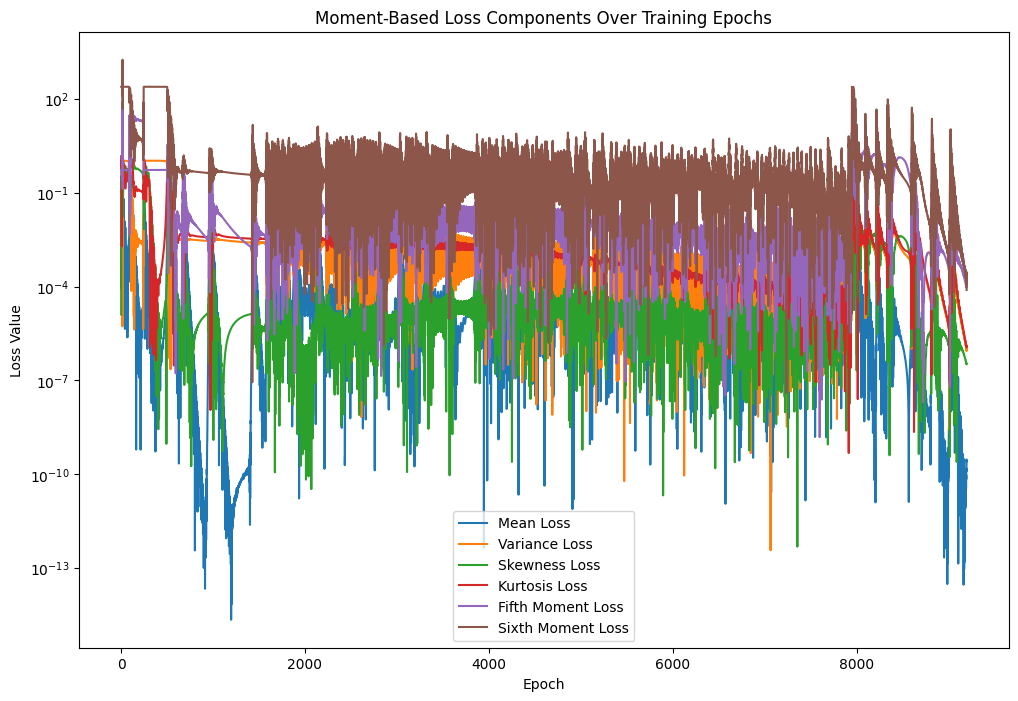

In [20]:
# Plot each loss component
plt.figure(figsize=(12, 8))
plt.yscale('log')
plt.plot(epoch_list, mean_loss_list, label="Mean Loss")
plt.plot(epoch_list, variance_loss_list, label="Variance Loss")
plt.plot(epoch_list, skewness_loss_list, label="Skewness Loss")
plt.plot(epoch_list, kurtosis_loss_list, label="Kurtosis Loss")
plt.plot(epoch_list, fifth_moment_loss_list, label="Fifth Moment Loss")
plt.plot(epoch_list, sixth_moment_loss_list, label="Sixth Moment Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss Value")
plt.title("Moment-Based Loss Components Over Training Epochs")
plt.legend()
plt.show()

Text(0, 0.5, '$l_2$')

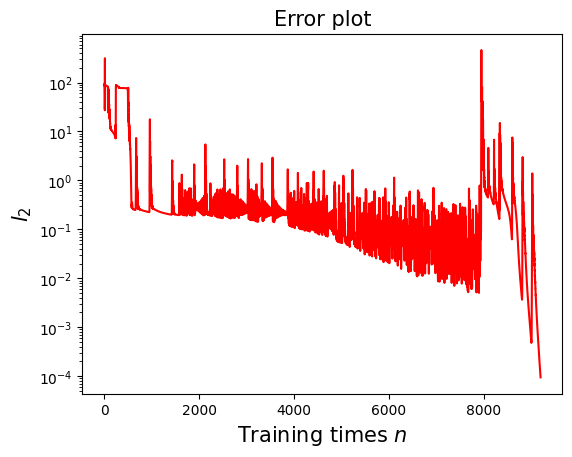

In [21]:
fig = plt.figure(1)
ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])
plt.title("Error plot",fontsize=15) 
plt.yscale('log')
plt.plot(epoch_list, total_loss_list,'r',label='Training error')
plt.xlabel(r'Training times $n$',fontsize=15)
plt.ylabel(r'$l_2$',fontsize=15)

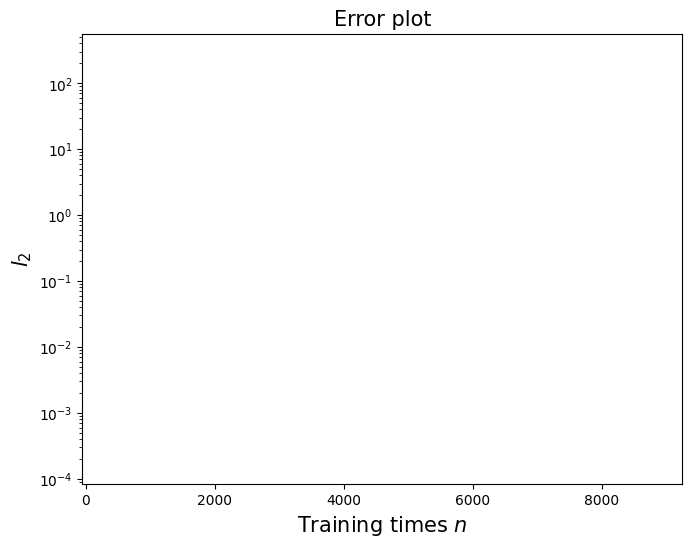

In [22]:
# Initialize figure
fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])
ax.set_title("Error plot", fontsize=15)
ax.set_xlabel(r'Training times $n$', fontsize=15)
ax.set_ylabel(r'$l_2$', fontsize=15)
ax.set_yscale('log')  # Use logarithmic scale for better visualization
ax.set_xlim(-50, epoch_list[-1]+50)  # Initial x-axis limit
ax.set_ylim(min(total_loss_list)-0.00001, max(total_loss_list)+100)  # Set y-axis limit

# Initialize line plot object (empty initially)
line, = ax.plot([], [], 'r', label='Training error')

# Function to update the plot in the animation
def update_plot(frame):
    # Show 10 more points at each frame
    end_index = (frame + 1) * save_interval
    epoch_data = epoch_list[:end_index]
    loss_data = total_loss_list[:end_index]
    
    # Update the line data
    line.set_data(epoch_data, loss_data)
    
    # Update the title to reflect the current epoch range
    ax.set_title(f"Error plot from Epoch 1 to Epoch {epoch_data[-1]}", fontsize=15)
    
    return line,

# Number of frames to show (every 10 epochs)
num_frames = len(epoch_list) // save_interval  # Adjust for how many epochs you have
if len(epoch_list) % save_interval != 0:
    num_frames += 1

# Create the animation
anim = FuncAnimation(fig, update_plot, frames=num_frames, interval=50, repeat=False)

# Show the animation
plt.show()

# Optionally save the animation as a GIF
anim.save("error_plot_animation.gif", writer="pillow", fps=20)


In [23]:
# Set the input for testing the transformation
input_test = torch.tensor(np.linspace(0, 1, batch_size).astype(np.float32)).unsqueeze(1)
uniform_samples_np = uniform_samples.numpy()
gaussian_samples_np = gaussian_samples.numpy()

In [24]:
# Function to load model and transform samples
def load_and_transform(model, model_path, input_test):
    model.load_state_dict(torch.load(model_path))
    model.eval()  # Set model to evaluation mode
    with torch.no_grad():
        transformed_samples = model(input_test)
    return transformed_samples.numpy()

In [25]:
# Get list of saved models sorted by creation time
model_files = sorted(glob.glob("model_epoch_*.pt"), key=os.path.getmtime)

if not model_files:
    print("No model files found.")
else:
    # Collect transformed samples for each saved model
    transformed_samples_list = [load_and_transform(model, path, input_test) for path in model_files]

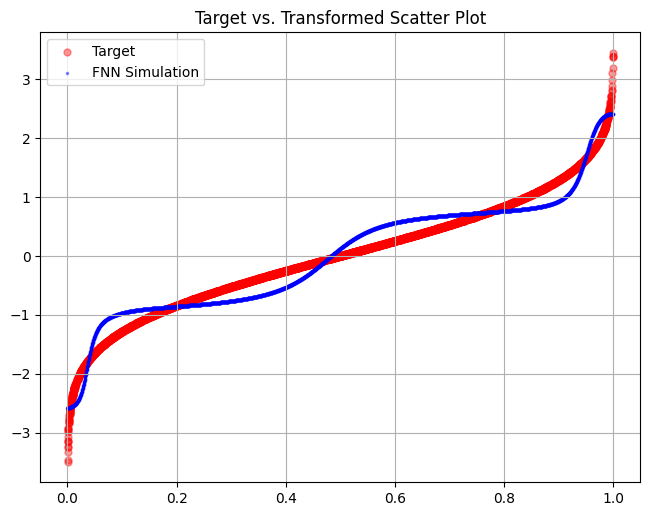

In [27]:
# Set up the figure with two subplots
fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])

# Scatter plot
scatter_target = ax.scatter(uniform_samples_np, gaussian_samples_np, c='r', s=25, alpha=0.4, marker='o', label='Target')
scatter_sim = ax.scatter(input_test.numpy(), transformed_samples_list[-1], c='b', s=10, alpha=0.4, marker='.', label='FNN Simulation')
ax.legend()
ax.set_title("Target vs. Transformed Scatter Plot")
ax.grid(True)


In [28]:
# Animation function
def animate(i):
    # Update scatter plot for FNN simulation
    epoch = int(model_files[i].split('_')[-1].split('.')[0])
    scatter_sim.set_offsets(np.c_[input_test.numpy(), transformed_samples_list[i]])
    ax.set_title(f"Scatter Plot at Epoch {epoch}")

In [29]:
# Create the animation
anim = FuncAnimation(fig, animate, frames=len(transformed_samples_list), interval=50)
%matplotlib inline
# Display the animation
plt.show()
# Save animation
anim.save("training_animation.gif", writer="pillow", fps=20)

# Combined

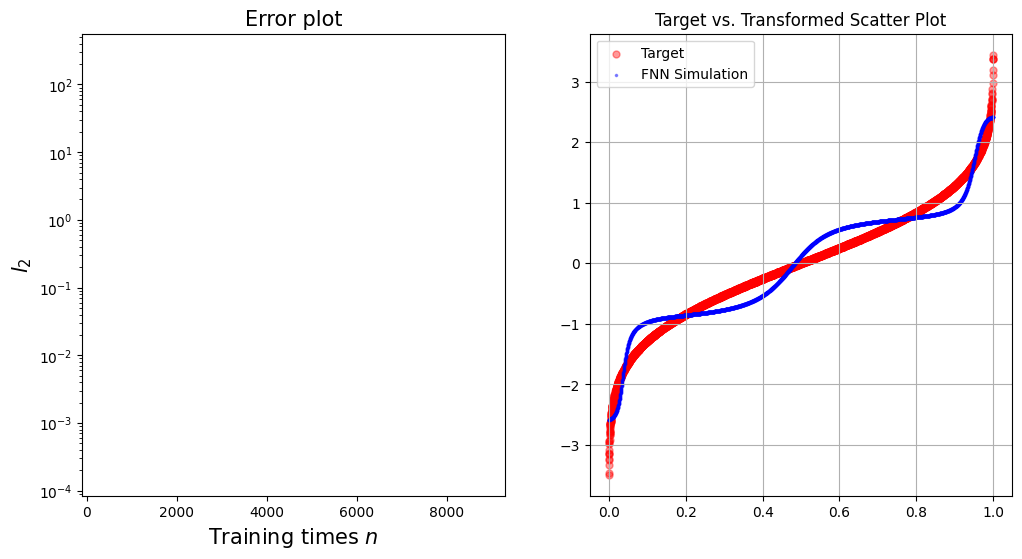

In [30]:
# Set up the figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Total loss plot (ax1)
ax1.set_title("Error plot", fontsize=15)
ax1.set_xlabel(r'Training times $n$', fontsize=15)
ax1.set_ylabel(r'$l_2$', fontsize=15)
ax1.set_yscale('log')  # Use logarithmic scale for better visualization
ax1.set_xlim(-100, epoch_list[-1]+100)  # Initial x-axis limit
ax1.set_ylim(min(total_loss_list)-0.00001, max(total_loss_list)+100)  # Set y-axis limit
line, = ax1.plot([], [], 'r', label='Training error')

# Scatter plot (ax2)
scatter_target = ax2.scatter(uniform_samples_np, gaussian_samples_np, c='r', s=25, alpha=0.4, marker='o', label='Target')
scatter_sim = ax2.scatter(input_test.numpy(), transformed_samples_list[-1], c='b', s=10, alpha=0.4, marker='.', label='FNN Simulation')
ax2.legend()
ax2.set_title("Target vs. Transformed Scatter Plot")
ax2.grid(True)

# Function to update both the total loss plot and scatter plot
def update_plot(frame):
    # Update total loss plot (ax1)
    end_index = (frame + 1) * save_interval
    epoch_data = epoch_list[:end_index]
    loss_data = total_loss_list[:end_index]
    line.set_data(epoch_data, loss_data)
    
    # Update scatter plot (ax2) for FNN simulation
    scatter_sim.set_offsets(np.c_[input_test.numpy(), transformed_samples_list[frame]])
    
    # Update titles
    ax1.set_title(f"Error plot from Epoch 1 to Epoch {epoch_data[-1]}", fontsize=15)
    ax2.set_title(f"Scatter Plot at Epoch {frame * save_interval}", fontsize=15)
    
    return line, scatter_sim  # Return the updated plot elements

# Number of frames to show (every 10 epochs)
num_frames = len(epoch_list) // save_interval  # Adjust for how many epochs you have
if len(epoch_list) % save_interval != 0:
    num_frames += 1

# Create the combined animation
anim = FuncAnimation(fig, update_plot, frames=num_frames, interval=50, repeat=False)

# Show the animation
plt.show()

# Optionally, save the animation as a GIF
anim.save("combined_training_animation.gif", writer="pillow", fps=20)

In [37]:
# Test the transformation from final model
with torch.no_grad():
    transformed_samples = model(input_test)


# Convert tensors to numpy for visualization
transformed_samples_np = transformed_samples.numpy()

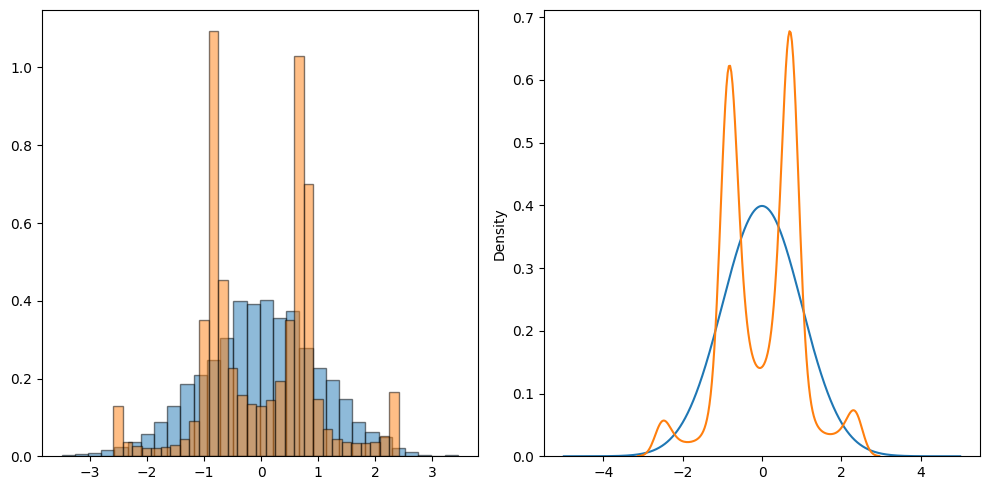

In [38]:
# Step 7: Plot the original and transformed distributions
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(gaussian_samples_np, bins=30, alpha=0.5, density=True, edgecolor='black')
plt.hist(transformed_samples_np, bins=30, alpha=0.5, density=True, edgecolor='black')
# plt.title('Gaussian vs Transformed Distribution')
# plt.legend()

plt.subplot(1, 2, 2)
# Gaussian distribution with Mean = 0, SD = 1.
x_axis = np.arange(-5, 5, 0.0005)
plt.plot(x_axis, norm.pdf(x_axis,0,1))
sns.kdeplot(transformed_samples.cpu().reshape(batch_size))
# plt.title('Gaussian vs Transformed Distribution')

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Frequency')

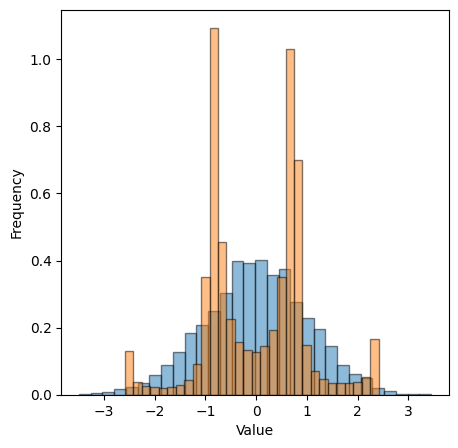

In [39]:
plt.figure(figsize=(5, 5))
plt.hist(gaussian_samples_np, bins=30, alpha=0.5, density=True, edgecolor='black')
plt.hist(transformed_samples_np, bins=30, alpha=0.5, density=True, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Frequency')
# plt.title('Gaussian vs Transformed Distribution')

Text(0.5, 0, 'Value')

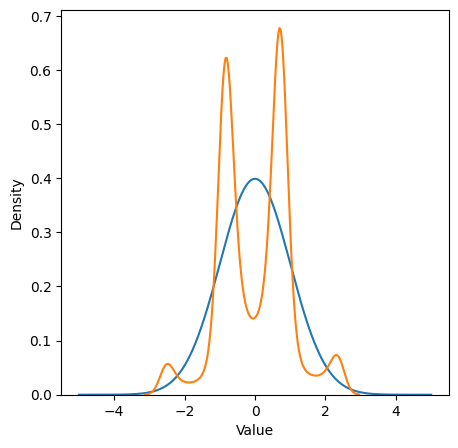

In [40]:
plt.figure(figsize=(5, 5))
# Normal distribution with Mean = 0, SD = 1.
x_axis = np.arange(-5, 5, 0.0005)
plt.plot(x_axis, norm.pdf(x_axis,0,1))
sns.kdeplot(transformed_samples.cpu().reshape(batch_size))
# plt.title('Gaussian vs Transformed Distribution')
plt.xlabel('Value')

In [35]:
# Test the transformation from final model
with torch.no_grad():
    transformed_samples1 = model(uniform_samples)


print(compute_mean(transformed_samples1))
print(compute_variance(transformed_samples1))
print(compute_skewness(transformed_samples1))
print(compute_kurtosis(transformed_samples1))
print(compute_fifth_moment(transformed_samples1))
print(compute_fifth_moment(transformed_samples1))

tensor(0.0011)
tensor(1.0296)
tensor(-0.0779)
tensor(-0.0188)
tensor(-0.7397)
tensor(-0.7397)


In [36]:
print(compute_mean(gaussian_samples))
print(compute_variance(gaussian_samples))
print(compute_skewness(gaussian_samples))
print(compute_kurtosis(gaussian_samples))
print(compute_fifth_moment(gaussian_samples))
print(compute_fifth_moment(gaussian_samples))

tensor(0.0011, dtype=torch.float64)
tensor(1.0288, dtype=torch.float64)
tensor(-0.0785, dtype=torch.float64)
tensor(-0.0198, dtype=torch.float64)
tensor(-0.7304, dtype=torch.float64)
tensor(-0.7304, dtype=torch.float64)
